---

# Chapter 4 - Visualization

---

## Imports & Data Load

All imports and data for Chapter 4. Run this cell first.


In [3]:
# =========================================================
# CHAPTER 4 -- IMPORTS & DATA LOAD
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import os, sys

sys.path.insert(0, os.path.abspath('..'))

from src.config      import *
from src.data_loader import load_processed
from src.viz         import save_fig, fmt_currency, fmt_comma, add_avg_line

df = load_processed(verbose=True)
avg_denial = df['IS_DENIED'].mean() * 100

print(f'\n Chapter 4 ready -- {len(df):,} rows loaded')
print(f'     All figures -> {REPORTS_DIR}')


 Processed data loaded: 10,000 rows × 49 columns
  IS_DENIED: 503 denied (5.03%)

 Chapter 4 ready -- 10,000 rows loaded
     All figures -> C:\Users\Administrator\Desktop\insurance-claim-fraud-detection\reports


---

## 4.1 Portfolio Overview Dashboard

A single composite figure (6 panels) summarising the full portfolio. This is the opening figure for the research report.


 Saved → reports/fig13_portfolio_dashboard.png


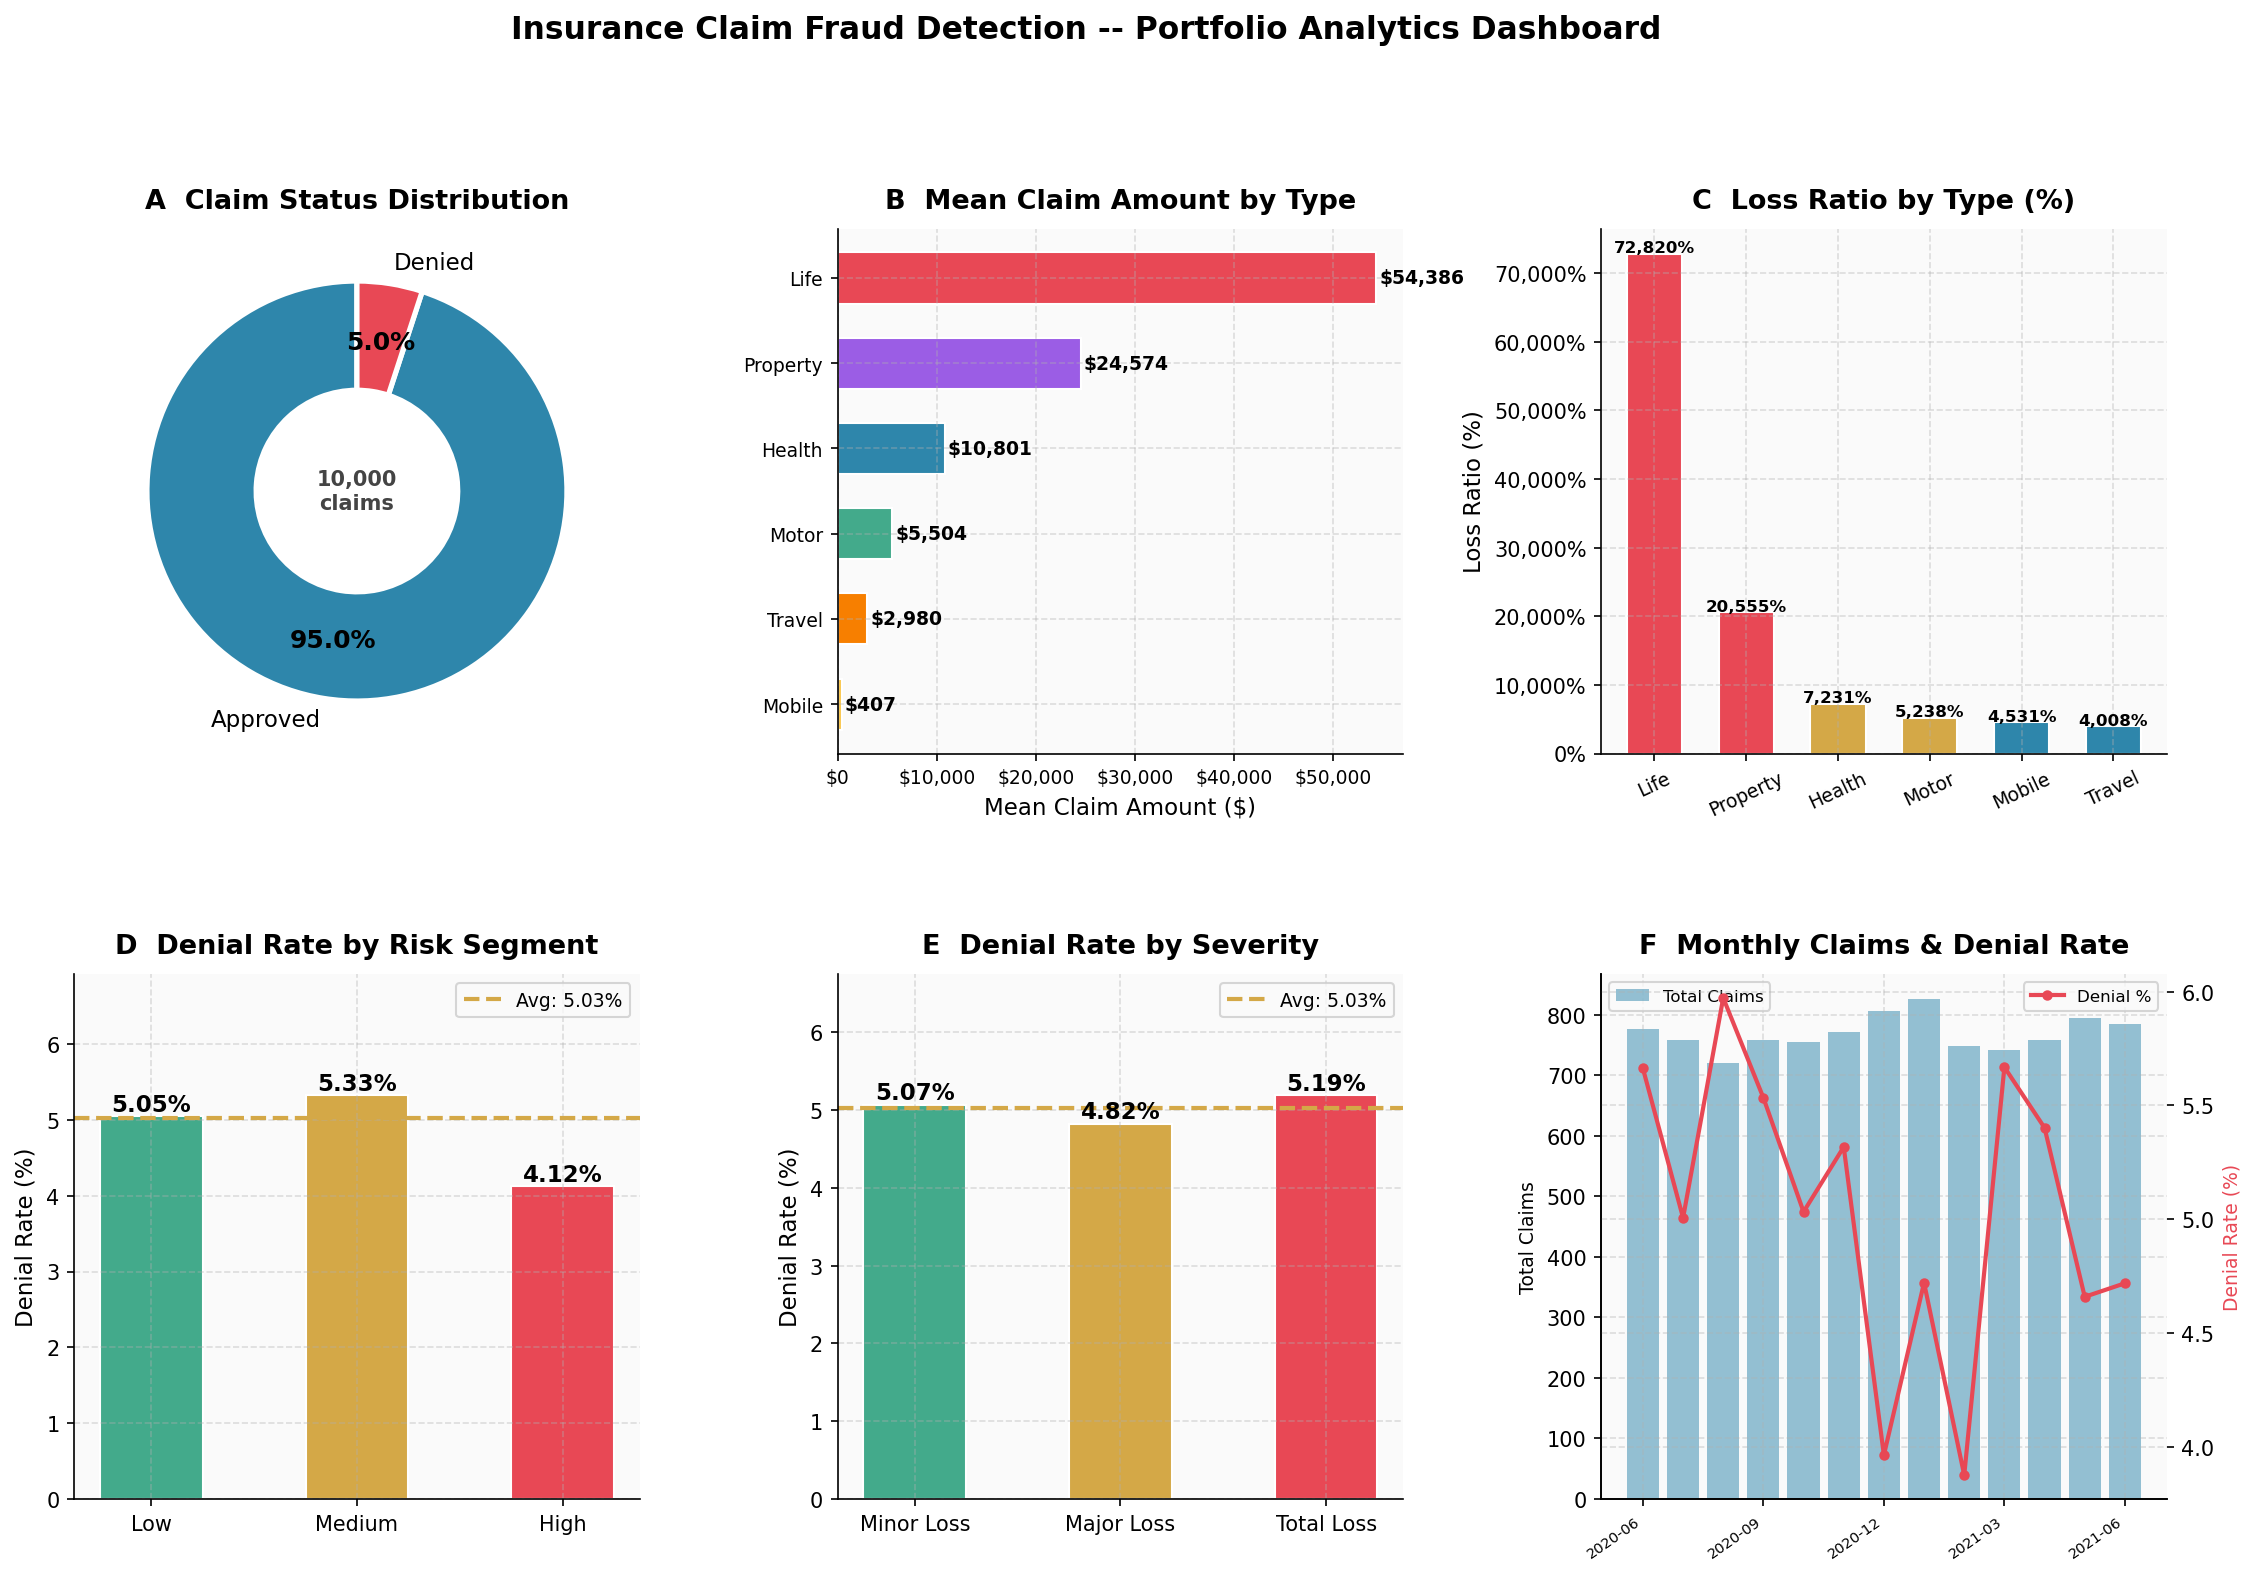

 Fig 13: Portfolio dashboard saved


In [4]:
# =========================================================
# 4.1 -- PORTFOLIO OVERVIEW DASHBOARD (6-panel)
# =========================================================

fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor('white')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# -- Panel A: Donut chart (target distribution) ----------
ax_a = fig.add_subplot(gs[0, 0])
counts = df['STATUS_LABEL'].value_counts()
wedges, texts, autotexts = ax_a.pie(
    counts.values, labels=counts.index,
    colors=[APPR_COLOR, DENY_COLOR],
    autopct='%1.1f%%', startangle=90, pctdistance=0.72,
    wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2.5),
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold'); at.set_fontsize(12)
ax_a.set_title('A  Claim Status Distribution', fontweight='bold', pad=10)
ax_a.text(0, 0, f'{len(df):,}\nclaims', ha='center', va='center',
           fontsize=10, fontweight='bold', color='#444')

# -- Panel B: Mean claim by insurance type ---------------
ax_b = fig.add_subplot(gs[0, 1])
type_means = df.groupby('INSURANCE_TYPE')['CLAIM_AMOUNT'].mean().sort_values()
hb = ax_b.barh(type_means.index, type_means.values,
                color=[TYPE_COLORS[t] for t in type_means.index],
                edgecolor='white', height=0.6)
for bar, val in zip(hb, type_means.values):
    ax_b.text(val+300, bar.get_y()+bar.get_height()/2,
              f'${val:,.0f}', va='center', fontsize=9, fontweight='bold')
ax_b.set_title('B  Mean Claim Amount by Type', fontweight='bold', pad=10)
ax_b.set_xlabel('Mean Claim Amount ($)')
fmt_currency(ax_b, 'x')
ax_b.tick_params(labelsize=9)

# -- Panel C: Loss ratio by type -------------------------
ax_c = fig.add_subplot(gs[0, 2])
lr = df.groupby('INSURANCE_TYPE').apply(
    lambda x: x['CLAIM_AMOUNT'].sum() / x['PREMIUM_AMOUNT'].sum() * 100
).sort_values(ascending=False)
colors_c = [DENY_COLOR if v > 10000 else GOLD_COLOR if v > 5000 else APPR_COLOR
             for v in lr.values]
vb = ax_c.bar(lr.index, lr.values, color=colors_c, edgecolor='white', width=0.6)
ax_c.set_title('C  Loss Ratio by Type (%)', fontweight='bold', pad=10)
ax_c.set_ylabel('Loss Ratio (%)')
ax_c.tick_params(axis='x', rotation=25, labelsize=9)
ax_c.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}%'))
for bar, val in zip(vb, lr.values):
    ax_c.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
              f'{val:,.0f}%', ha='center', fontsize=8, fontweight='bold')

# -- Panel D: Denial rate by risk segment ----------------
ax_d = fig.add_subplot(gs[1, 0])
risk_denial = df.groupby('RISK_LABEL').apply(
    lambda x: x['IS_DENIED'].mean()*100).reindex(RISK_SEGMENTS)
rd = ax_d.bar(RISK_SEGMENTS, risk_denial.values,
               color=['#43AA8B', GOLD_COLOR, DENY_COLOR],
               width=0.5, edgecolor='white')
add_avg_line(ax_d, avg_denial, label=f'Avg: {avg_denial:.2f}%', orient='h')
for bar, val in zip(rd, risk_denial.values):
    ax_d.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.07,
              f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')
ax_d.set_title('D  Denial Rate by Risk Segment', fontweight='bold', pad=10)
ax_d.set_ylabel('Denial Rate (%)')
ax_d.set_ylim(0, risk_denial.max()*1.3)
ax_d.legend(fontsize=9)

# -- Panel E: Denial by severity -------------------------
ax_e = fig.add_subplot(gs[1, 1])
sev_denial = df.groupby('INCIDENT_SEVERITY').apply(
    lambda x: x['IS_DENIED'].mean()*100).reindex(SEVERITY_LEVELS)
se = ax_e.bar(SEVERITY_LEVELS, sev_denial.values,
               color=['#43AA8B', GOLD_COLOR, DENY_COLOR],
               width=0.5, edgecolor='white')
add_avg_line(ax_e, avg_denial, label=f'Avg: {avg_denial:.2f}%', orient='h')
for bar, val in zip(se, sev_denial.values):
    ax_e.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.07,
              f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')
ax_e.set_title('E  Denial Rate by Severity', fontweight='bold', pad=10)
ax_e.set_ylabel('Denial Rate (%)')
ax_e.set_ylim(0, sev_denial.max()*1.3)
ax_e.legend(fontsize=9)

# -- Panel F: Monthly trend ------------------------------
ax_f  = fig.add_subplot(gs[1, 2])
ax_f2 = ax_f.twinx()
df['TXN_MONTH'] = df['TXN_DATE_TIME'].dt.to_period('M')
monthly = df.groupby('TXN_MONTH').agg(
    total=('IS_DENIED','count'), denied=('IS_DENIED','sum')).reset_index()
monthly['denial_rate'] = monthly['denied'] / monthly['total'] * 100
ax_f.bar(range(len(monthly)), monthly['total'],
          color=APPR_COLOR, alpha=0.5, label='Total Claims')
ax_f2.plot(range(len(monthly)), monthly['denial_rate'],
            color=DENY_COLOR, linewidth=2, marker='o', markersize=4, label='Denial %')
ax_f.set_xticks(range(0, len(monthly), 3))
ax_f.set_xticklabels(monthly['TXN_MONTH'].astype(str).iloc[::3],
                      rotation=35, ha='right', fontsize=7)
ax_f.set_title('F  Monthly Claims & Denial Rate', fontweight='bold', pad=10)
ax_f.set_ylabel('Total Claims', fontsize=9)
ax_f2.set_ylabel('Denial Rate (%)', color=DENY_COLOR, fontsize=9)
ax_f.legend(loc='upper left', fontsize=8)
ax_f2.legend(loc='upper right', fontsize=8)

fig.suptitle('Insurance Claim Fraud Detection -- Portfolio Analytics Dashboard',
             fontsize=15, fontweight='bold', y=1.01)

save_fig('fig13_portfolio_dashboard.png', dpi=180)
plt.show()
print(' Fig 13: Portfolio dashboard saved')


**Figure 13** is the primary portfolio level dashboard. Six panels in one view:
claim status split, mean claim by type, loss ratio, denial by risk, denial by severity,
and monthly volume trend.

---

## 4.2 Risk x Severity Heatmaps

Two heatmaps showing mean claim amount and denial rate across the two most important
categorical dimensions. A quick visual test of interaction effects.


 Saved → reports/fig14_risk_severity_heatmap.png


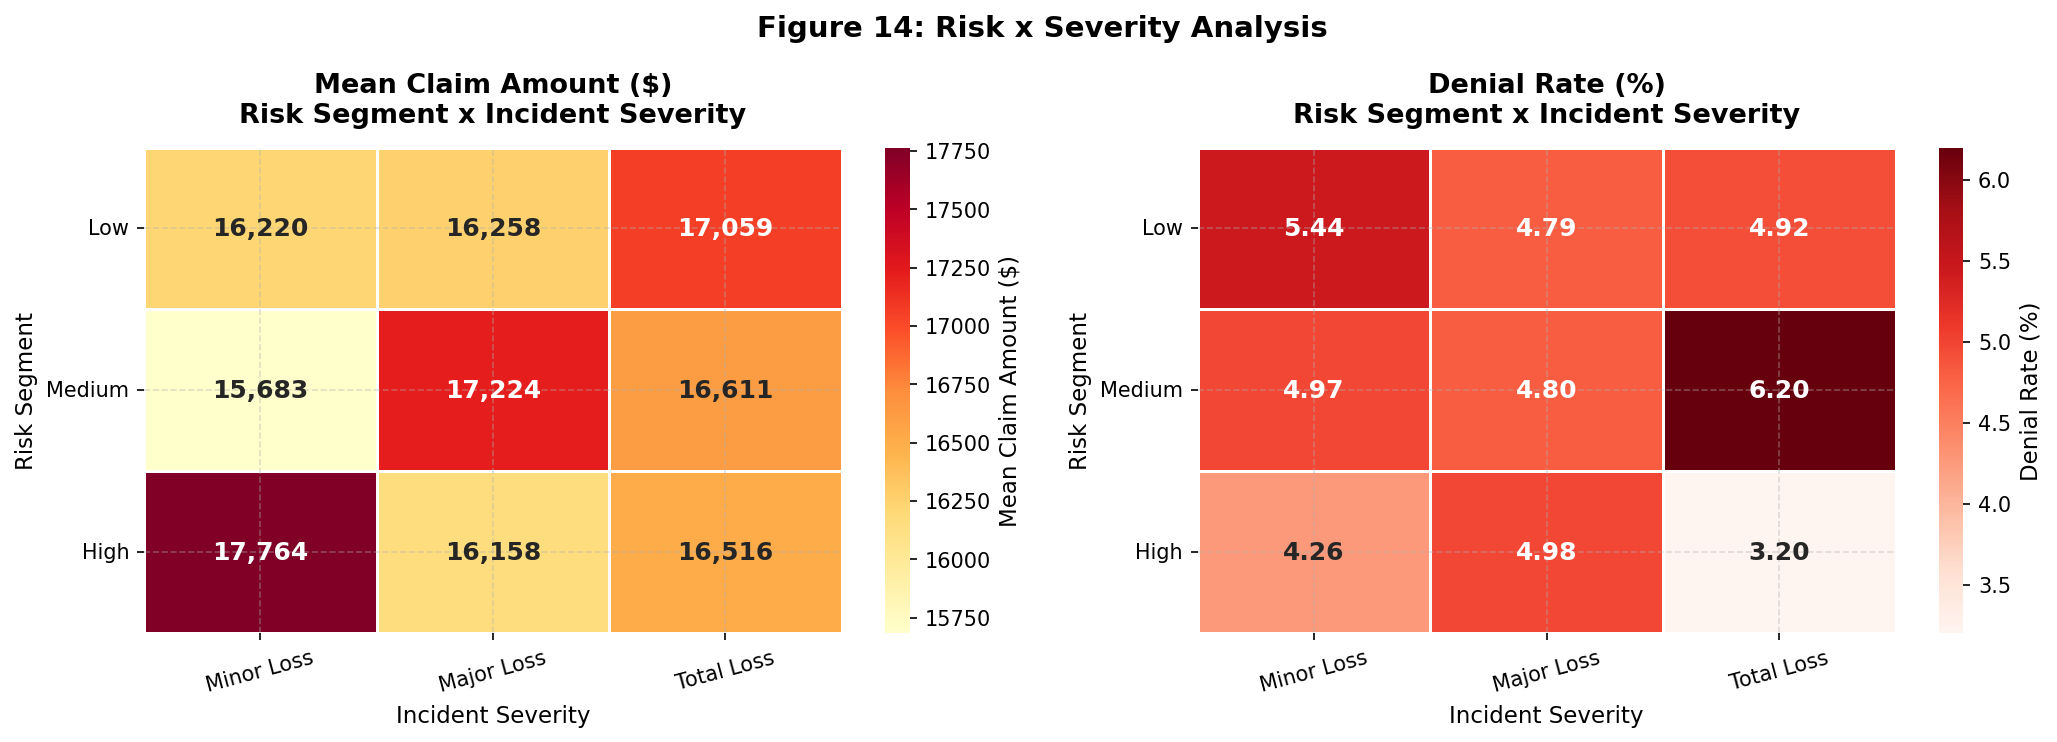

 Fig 14 saved


In [5]:
# =========================================================
# 4.2 -- RISK x SEVERITY HEATMAPS
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 14: Risk x Severity Analysis', fontsize=14, fontweight='bold')

# Left: Mean claim amount
pivot_amt = df.pivot_table(
    values='CLAIM_AMOUNT', index='RISK_LABEL',
    columns='INCIDENT_SEVERITY', aggfunc='mean'
).reindex(RISK_SEGMENTS)[SEVERITY_LEVELS]

sns.heatmap(pivot_amt, annot=True, fmt=',.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=axes[0],
            cbar_kws={'label': 'Mean Claim Amount ($)'},
            annot_kws={'size': 12, 'weight': 'bold'})
axes[0].set_title('Mean Claim Amount ($)\nRisk Segment x Incident Severity', pad=12)
axes[0].set_xlabel('Incident Severity')
axes[0].set_ylabel('Risk Segment')
axes[0].tick_params(axis='x', rotation=15)
axes[0].tick_params(axis='y', rotation=0)

# Right: Denial rate
pivot_den = df.pivot_table(
    values='IS_DENIED', index='RISK_LABEL',
    columns='INCIDENT_SEVERITY', aggfunc='mean'
).reindex(RISK_SEGMENTS)[SEVERITY_LEVELS] * 100

sns.heatmap(pivot_den, annot=True, fmt='.2f', cmap='Reds',
            linewidths=0.5, linecolor='white', ax=axes[1],
            cbar_kws={'label': 'Denial Rate (%)'},
            annot_kws={'size': 12, 'weight': 'bold'})
axes[1].set_title('Denial Rate (%)\nRisk Segment x Incident Severity', pad=12)
axes[1].set_xlabel('Incident Severity')
axes[1].set_ylabel('Risk Segment')
axes[1].tick_params(axis='x', rotation=15)
axes[1].tick_params(axis='y', rotation=0)

save_fig('fig14_risk_severity_heatmap.png')
plt.show()
print(' Fig 14 saved')


**Interpretation:** Both heatmaps show minimal gradients across cells -- reinforcing the H2 finding that risk segmentation and severity do not strongly interact to produce distinct denial patterns. Medium-risk / Total Loss shows the highest denial rate (5.57%) but the spread is narrow.

---

## 4.3 Temporal & Behavioural Patterns


 Saved → reports/fig15_temporal_patterns.png


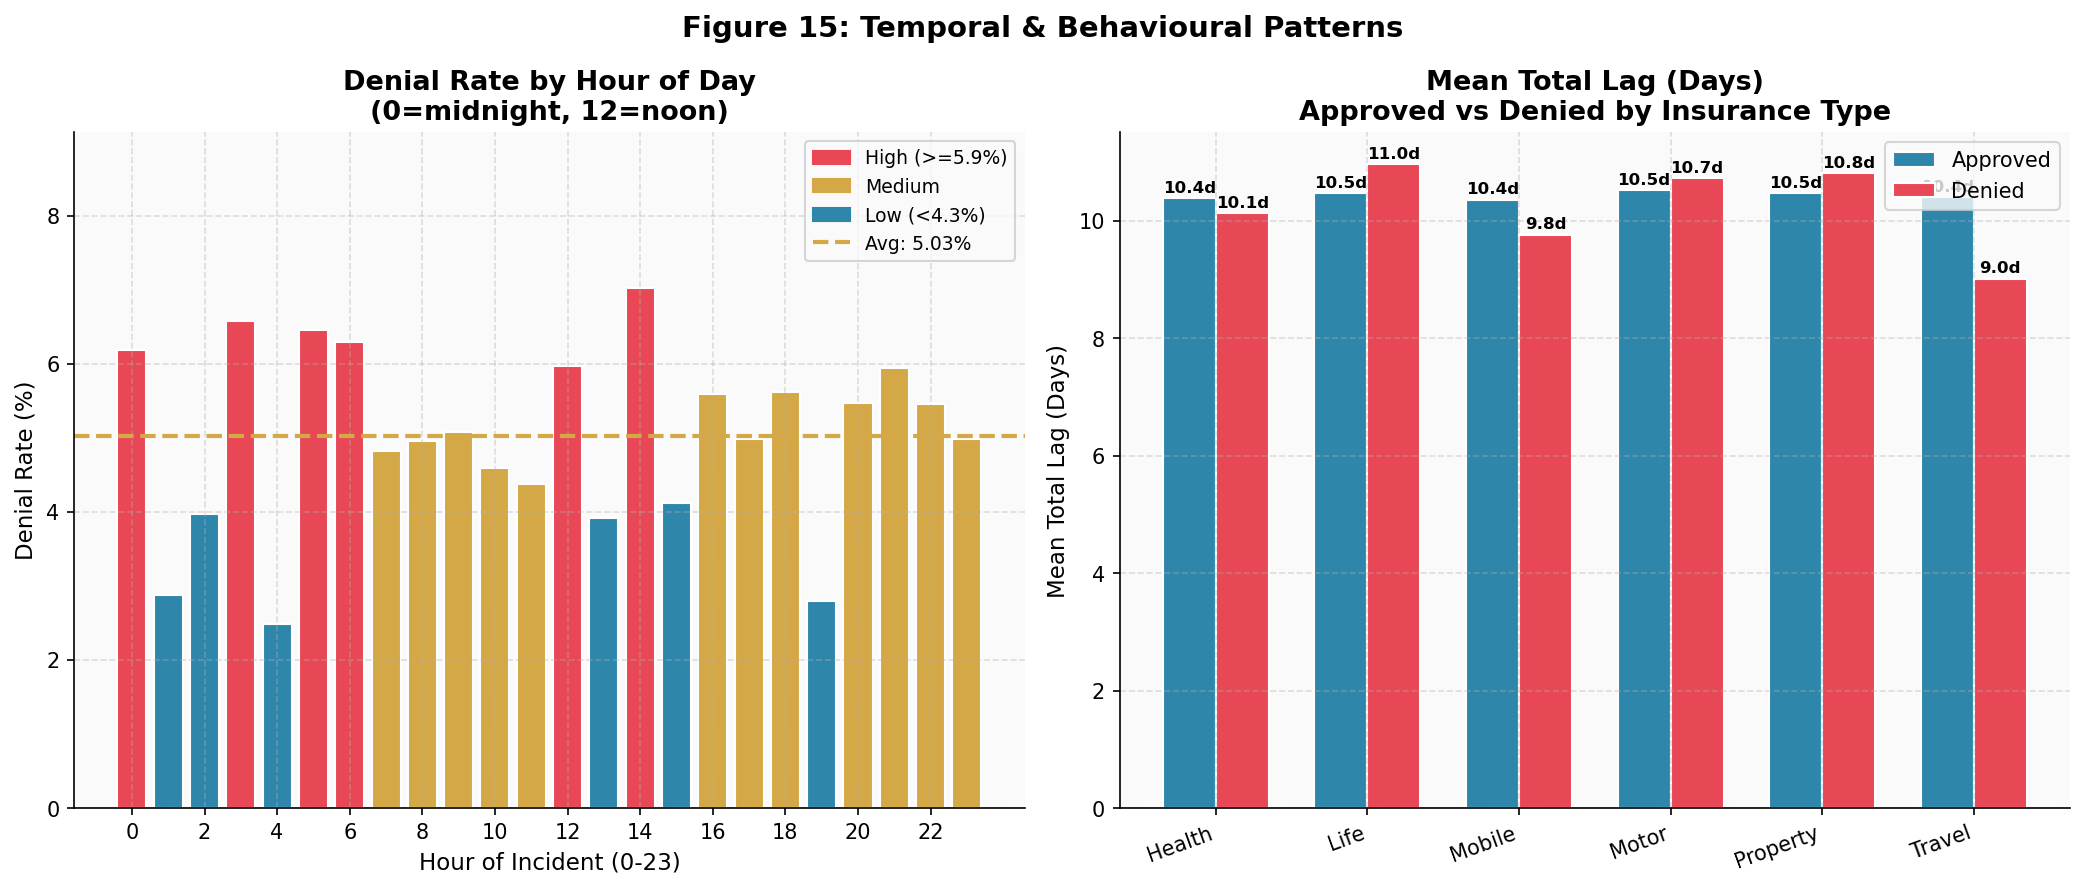

 Fig 15 saved
Note: Hour 14 has highest denial rate at 7.02%


In [6]:
# =========================================================
# 4.3 -- TEMPORAL PATTERNS: HOUR OF DAY + LAG BY TYPE
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 15: Temporal & Behavioural Patterns', fontsize=14, fontweight='bold')

# Left: Denial rate by hour of day
hour_denial = df.groupby('INCIDENT_HOUR_OF_THE_DAY')['IS_DENIED'].mean() * 100
q25, q75    = hour_denial.quantile(0.25), hour_denial.quantile(0.75)
colors_h    = [DENY_COLOR if v >= q75 else GOLD_COLOR if v >= q25 else APPR_COLOR
                for v in hour_denial.values]

axes[0].bar(hour_denial.index, hour_denial.values, color=colors_h,
             width=0.8, edgecolor='white')
add_avg_line(axes[0], avg_denial, label=f'Portfolio avg: {avg_denial:.2f}%', orient='h')
axes[0].set_title('Denial Rate by Hour of Day\n(0=midnight, 12=noon)')
axes[0].set_xlabel('Hour of Incident (0-23)')
axes[0].set_ylabel('Denial Rate (%)')
axes[0].set_xticks(range(0, 24, 2))
axes[0].set_ylim(0, hour_denial.max() * 1.3)
legend_patches = [
    mpatches.Patch(color=DENY_COLOR, label=f'High (>={q75:.1f}%)'),
    mpatches.Patch(color=GOLD_COLOR, label='Medium'),
    mpatches.Patch(color=APPR_COLOR, label=f'Low (<{q25:.1f}%)'),
    plt.Line2D([0],[0], color=GOLD_COLOR, linestyle='--',
                linewidth=2, label=f'Avg: {avg_denial:.2f}%'),
]
axes[0].legend(handles=legend_patches, fontsize=9)

# Right: Total lag by type x status
lag_data = df.groupby(['INSURANCE_TYPE','STATUS_LABEL'])['TOTAL_LAG_DAYS'].mean().unstack()
x, w = np.arange(len(lag_data)), 0.35
b1 = axes[1].bar(x-w/2, lag_data['Approved'], width=w,
                  color=APPR_COLOR, label='Approved', edgecolor='white')
b2 = axes[1].bar(x+w/2, lag_data['Denied'],   width=w,
                  color=DENY_COLOR,  label='Denied',   edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(lag_data.index, rotation=20, ha='right', fontsize=10)
axes[1].set_title('Mean Total Lag (Days)\nApproved vs Denied by Insurance Type')
axes[1].set_ylabel('Mean Total Lag (Days)')
axes[1].legend(fontsize=10)
for bars in [b1, b2]:
    for bar in bars:
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                     f'{bar.get_height():.1f}d', ha='center', fontsize=8, fontweight='bold')

save_fig('fig15_temporal_patterns.png')
plt.show()
print(' Fig 15 saved')
print(f'Note: Hour 14 has highest denial rate at {hour_denial[14]:.2f}%')


**Interpretation:** Hour 14 (2 pm) shows the highest denial rate (7.02%), followed by hours 3 and 0 (overnight incidents). This may reflect incidents where documentation is harder to obtain. Total lag is near identical across insurance types for approved vs denied claims -- consistent with H4.

---

## 4.4 Two-Dimensional Denial Heatmaps


In [ ]:
# =========================================================
# 4.4 -- DENIAL RATE: INSURANCE TYPE x SOCIAL CLASS
#                     INSURANCE TYPE x EDUCATION LEVEL
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Figure 16: Two-Dimensional Denial Rate Breakdowns',
             fontsize=14, fontweight='bold')

# Left: Type x Social Class
class_order  = ['Low Income', 'Mid Income', 'High Income']
pivot_tc = df.pivot_table(
    values='IS_DENIED', index='INSURANCE_TYPE',
    columns='CLASS_LABEL', aggfunc='mean'
)[class_order] * 100

sns.heatmap(pivot_tc, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=avg_denial, linewidths=0.5, linecolor='white',
            ax=axes[0], cbar_kws={'label': 'Denial Rate (%)'},
            annot_kws={'size': 11, 'weight': 'bold'})
axes[0].set_title('Denial Rate (%)\nInsurance Type x Social Class', pad=12)
axes[0].set_xlabel('Social Class')
axes[0].set_ylabel('Insurance Type')
axes[0].tick_params(axis='x', rotation=15)

# Right: Type x Education
edu_order = ['High School','College','Bachelor','Masters','MD','PhD','Unknown']
pivot_te  = df.pivot_table(
    values='IS_DENIED', index='INSURANCE_TYPE',
    columns='CUSTOMER_EDUCATION_LEVEL', aggfunc='mean'
) * 100
pivot_te  = pivot_te[[e for e in edu_order if e in pivot_te.columns]]

sns.heatmap(pivot_te, annot=True, fmt='.1f', cmap='RdYlGn_r',
            center=avg_denial, linewidths=0.5, linecolor='white',
            ax=axes[1], cbar_kws={'label': 'Denial Rate (%)'},
            annot_kws={'size': 9, 'weight': 'bold'})
axes[1].set_title('Denial Rate (%)\nInsurance Type x Education Level', pad=12)
axes[1].set_xlabel('Education Level')
axes[1].set_ylabel('Insurance Type')
axes[1].tick_params(axis='x', rotation=25)

save_fig('fig16_denial_heatmaps.png')
plt.show()
print(' Fig 16 saved')
